# NB7: Combined Feature Analysis (Old + New Descriptors)

**Goal:** Merge best features from old nb6 (point-based) and new nb6 (plane-based),
define 10 feature combinations, and test each on 4 scenarios:

| | Regression (LOO R2) | Classification (LOO F1, threshold 1.5) |
|---|---|---|
| **205 rows** | GroupLeaveOneOut by uid | GroupLeaveOneOut by uid |
| **99 rows** | Standard LOO | Standard LOO |

**Location:** `Keshav-DDP/k-path/old+new_nb6/nb7_combined_analysis.ipynb`

## Cell 1: Configuration

In [1]:
import os

# =============================================================================
# PATHS -- CHANGE THESE IF YOU MOVE THE NOTEBOOK
# =============================================================================

# Parent: Keshav-DDP/k-path/old+new_nb6/
# Go up two levels to reach Keshav-DDP/
BASE_DIR = os.path.abspath(os.path.join("..", ".."))

# Old nb6 CSV (point-based descriptors, 205 rows)
OLD_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors_old.csv"
)

# New nb6 CSV (plane-based descriptors, 205 rows)
NEW_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors.csv"
)

# Output
RESULTS_DIR = os.path.join(".", "nb7_combined-results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# =============================================================================
print("=" * 65)
print("  PATH CONFIGURATION")
print("=" * 65)
for name, path in [("BASE_DIR", BASE_DIR), ("OLD_CSV", OLD_CSV),
                    ("NEW_CSV", NEW_CSV), ("RESULTS_DIR", RESULTS_DIR)]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  [{status:7s}] {name:15s} = {path}")

  PATH CONFIGURATION
  [OK     ] BASE_DIR        = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP
  [OK     ] OLD_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors_old.csv
  [OK     ] NEW_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors.csv
  [OK     ] RESULTS_DIR     = .\nb7_combined-results


## Cell 2: Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from time import time

from sklearn.model_selection import (
    LeaveOneOut, LeaveOneGroupOut, GroupKFold, StratifiedKFold,
    cross_val_score, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_absolute_error, f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, classification_report
)
from xgboost import XGBRegressor, XGBClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

print("Imports OK.")

Imports OK.


## Cell 3: Load and merge CSVs

In [3]:
df_old = pd.read_csv(OLD_CSV)
df_new = pd.read_csv(NEW_CSV)

print(f"Old CSV: {df_old.shape[0]} rows, {df_old.shape[1]} columns")
print(f"New CSV: {df_new.shape[0]} rows, {df_new.shape[1]} columns")

# Identify shared ID columns
ID_COLS = ['Formula', 'uid', 'kpath', 'Rashba_parameter']
TARGET = 'Rashba_parameter'

# Merge on ID columns (inner join to keep only matching rows)
# Suffix old features with _old if they clash with new features
df_merged = df_old[ID_COLS].copy()

# Add old features (prefix old_ for features that exist in both)
old_features_to_add = [c for c in df_old.columns if c not in ID_COLS]
new_features_to_add = [c for c in df_new.columns if c not in ID_COLS]

# Find overlapping feature names
overlap = set(old_features_to_add) & set(new_features_to_add)
print(f"\nOverlapping feature names: {len(overlap)}")
if overlap:
    print(f"  {sorted(overlap)[:10]}...")

# Add old features
for col in old_features_to_add:
    new_name = f"old_{col}" if col in overlap else col
    df_merged[new_name] = df_old[col].values

# Add new features
for col in new_features_to_add:
    new_name = f"new_{col}" if col in overlap else col
    if new_name not in df_merged.columns:  # avoid duplicates
        df_merged[new_name] = df_new[col].values

print(f"\nMerged: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")
print(f"  ID columns: {len(ID_COLS)}")
print(f"  Feature columns: {df_merged.shape[1] - len(ID_COLS)}")

Old CSV: 205 rows, 1263 columns
New CSV: 205 rows, 134 columns

Overlapping feature names: 27
  ['E_pfrac_CBM', 'E_pfrac_VBM', 'E_pfrac_relevant', 'X_diff', 'X_mean', 'band_binary', 'bandgap', 'ehull', 'kend_frac_x', 'kend_frac_y']...

Merged: 205 rows, 1393 columns
  ID columns: 4
  Feature columns: 1389


## Cell 4: Define the 10 feature combinations

Each combo is tested on ALL 4 scenarios (same features everywhere).
Features from old CSV may need "old_" prefix if they overlap with new CSV features.
Adjust the names below based on actual column names after merge.

In [4]:
# Helper: check which columns actually exist
all_cols = set(df_merged.columns)

def resolve_features(feat_list):
    """
    Resolve feature names: check if they exist in merged df.
    Try original name first, then old_ prefix, then new_ prefix.
    """
    resolved = []
    missing = []
    for f in feat_list:
        if f in all_cols:
            resolved.append(f)
        elif f"old_{f}" in all_cols:
            resolved.append(f"old_{f}")
        elif f"new_{f}" in all_cols:
            resolved.append(f"new_{f}")
        else:
            missing.append(f)
    if missing:
        print(f"    WARNING: Missing features: {missing}")
    return resolved


# Define combinations
# NOTE: For 205 rows, E_pfrac_relevant is correct (varies per row based on band type).
# For 99 rows, we swap E_pfrac_relevant -> E_pfrac_VBM + E_pfrac_CBM (both band edges).
# This swap happens automatically in the evaluation functions below.

COMBOS = {
    "C1_proven_core": [
        "E_pfrac_relevant", "radius_mean", "ehull"
    ],
    "C2_old_best4": [
        "E_pfrac_relevant", "start_adf_min", "start_adf_n_triplets", "mid_nearest_Z"
    ],
    "C3_new_best4": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg"
    ],
    "C4_compact_mix": [
        "E_pfrac_relevant", "pmid_grdf_trig_max", "mid_nearest_Z",
        "kpath_angle_deg", "ehull"
    ],
    "C5_old_best7": [
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4"
    ],
    "C6_new_best7": [
        "pmid_grdf_trig_max", "E_pfrac_relevant", "E_pfrac_CBM",
        "radius_mean", "pmid_grdf_gauss_std", "kstart_frac_x", "pmid_afs_trig_mean"
    ],
    "C7_balanced_mix": [
        "E_pfrac_relevant", "pmid_grdf_trig_max", "mid_nearest_Z",
        "kpath_angle_deg", "ehull", "pstart_afs_gauss_std", "radius_mean", "band_binary"
    ],
    "C8_full_old_new": [
        "E_pfrac_relevant", "mid_nearest_Z", "mid_nearest_Z4", "kpath_angle_deg",
        "pmid_grdf_trig_max", "ehull", "pmid_afs_gauss_std", "radius_mean",
        "pstart_afs_gauss_std", "band_binary"
    ],
    "C9_kitchen_sink": [
        # Old best 7
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4",
        # + New best 6
        "pmid_grdf_trig_max", "ehull", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "radius_mean", "E_pfrac_CBM"
    ],
    "C10_everything": [
        # All unique top features from both
        "E_pfrac_relevant", "E_pfrac_CBM", "radius_mean", "ehull",
        "mid_nearest_Z", "mid_nearest_Z4", "n_elements", "sum_Z4",
        "kpath_angle_deg", "band_binary", "kstart_frac_y", "kend_frac_x", "kvec_z",
        "pmid_grdf_trig_max", "pend_grdf_trig_max", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "pstart_afs_bessel_std", "pmid_grdf_gauss_std",
        "start_adf_min", "start_adf_mean", "mid_adf_n_triplets", "mid_adf_max",
        "start_adf_n_triplets", "end_adf_n_triplets"
    ],
}


def swap_epfrac_for_99(features, df_cols):
    """
    For 99-row evaluation: replace E_pfrac_relevant with E_pfrac_VBM + E_pfrac_CBM.
    E_pfrac_relevant is band-specific (useful for 205 rows where rows have different bands).
    For 99 rows (one per compound), both VBM and CBM are available and informative.
    Also removes band_binary (meaningless for 99 rows since band varies per compound).
    """
    new_feats = []
    added_vbm_cbm = False

    for f in features:
        if 'E_pfrac_relevant' in f:
            if not added_vbm_cbm:
                # Find the actual column names (might have old_/new_ prefix)
                for candidate in ['E_pfrac_VBM', 'old_E_pfrac_VBM', 'new_E_pfrac_VBM']:
                    if candidate in df_cols:
                        new_feats.append(candidate)
                        break
                for candidate in ['E_pfrac_CBM', 'old_E_pfrac_CBM', 'new_E_pfrac_CBM']:
                    if candidate in df_cols:
                        new_feats.append(candidate)
                        break
                added_vbm_cbm = True
        elif 'band_binary' in f:
            continue  # skip band_binary for 99 rows
        else:
            new_feats.append(f)

    return new_feats


# Resolve all feature names
print("Resolving feature names:\n")
RESOLVED_COMBOS = {}
for name, feats in COMBOS.items():
    resolved = resolve_features(feats)
    RESOLVED_COMBOS[name] = resolved
    print(f"  {name}: {len(resolved)} features (205-row)")

# Also show what 99-row versions look like
print("\n99-row versions (E_pfrac_relevant -> VBM+CBM, drop band_binary):")
for name, feats in RESOLVED_COMBOS.items():
    feats_99 = swap_epfrac_for_99(feats, set(df_merged.columns))
    print(f"  {name}: {len(feats_99)} features")

Resolving feature names:

  C1_proven_core: 3 features (205-row)
  C2_old_best4: 4 features (205-row)
  C3_new_best4: 4 features (205-row)
  C4_compact_mix: 5 features (205-row)
  C5_old_best7: 7 features (205-row)
  C6_new_best7: 7 features (205-row)
  C7_balanced_mix: 8 features (205-row)
  C8_full_old_new: 10 features (205-row)
  C9_kitchen_sink: 13 features (205-row)
  C10_everything: 25 features (205-row)

99-row versions (E_pfrac_relevant -> VBM+CBM, drop band_binary):
  C1_proven_core: 4 features
  C2_old_best4: 5 features
  C3_new_best4: 5 features
  C4_compact_mix: 6 features
  C5_old_best7: 8 features
  C6_new_best7: 8 features
  C7_balanced_mix: 8 features
  C8_full_old_new: 10 features
  C9_kitchen_sink: 14 features
  C10_everything: 25 features


## Cell 5: Prepare 205-row and 99-row datasets

In [5]:
# 205-row dataset (all rows)
y_205 = df_merged[TARGET].values
groups_205 = df_merged['uid'].values
n_groups = len(np.unique(groups_205))

print(f"205-row dataset: {len(y_205)} rows, {n_groups} unique compounds")

# 99-row dataset (max alpha_R per uid)
idx_99 = df_merged.groupby('uid')[TARGET].idxmax()
df_99 = df_merged.loc[idx_99].reset_index(drop=True)
y_99 = df_99[TARGET].values

print(f"99-row dataset: {len(y_99)} rows (max alpha_R per compound)")
print(f"  alpha_R range: [{y_99.min():.3f}, {y_99.max():.3f}]")

# Classification target (threshold 1.5)
THRESHOLD = 1.5
y_class_205 = (y_205 >= THRESHOLD).astype(int)
y_class_99 = (y_99 >= THRESHOLD).astype(int)

print(f"\nClassification (threshold {THRESHOLD}):")
print(f"  205 rows: {y_class_205.sum()} positive, {len(y_class_205) - y_class_205.sum()} negative")
print(f"  99 rows:  {y_class_99.sum()} positive, {len(y_class_99) - y_class_99.sum()} negative")

205-row dataset: 205 rows, 99 unique compounds
99-row dataset: 99 rows (max alpha_R per compound)
  alpha_R range: [0.393, 4.804]

Classification (threshold 1.5):
  205 rows: 89 positive, 116 negative
  99 rows:  50 positive, 49 negative


## Cell 6: XGBoost configs

In [6]:
XGB_REG_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    random_state=42, verbosity=0
)

XGB_CLF_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=3,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0
)

print("XGBoost configs defined.")

XGBoost configs defined.


## Cell 7: Evaluation functions

In [7]:
def eval_regression_205(features, df, y, groups):
    """Regression on 205 rows with LeaveOneGroupOut (by uid)."""
    X = df[features].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    logo = LeaveOneGroupOut()
    y_pred = cross_val_predict(model, X, y, cv=logo, groups=groups)
    return {
        'loo_r2': r2_score(y, y_pred),
        'loo_mae': mean_absolute_error(y, y_pred),
    }


def eval_regression_99(features, df, y):
    """Regression on 99 rows with standard LOO. Uses VBM+CBM instead of E_pfrac_relevant."""
    features_99 = swap_epfrac_for_99(features, set(df.columns))
    X = df[features_99].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    loo = LeaveOneOut()
    y_pred = cross_val_predict(model, X, y, cv=loo)
    return {
        'loo_r2': r2_score(y, y_pred),
        'loo_mae': mean_absolute_error(y, y_pred),
        'features_used': features_99,
    }


def eval_classification_205(features, df, y_class, groups):
    """Classification on 205 rows with LeaveOneGroupOut."""
    X = df[features].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    logo = LeaveOneGroupOut()

    y_pred = cross_val_predict(model, X, y_class, cv=logo, groups=groups)
    try:
        y_prob = cross_val_predict(model, X, y_class, cv=logo, groups=groups,
                                   method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class, y_prob)
    except:
        auc = np.nan

    return {
        'loo_f1': f1_score(y_class, y_pred),
        'loo_auc': auc,
        'loo_acc': accuracy_score(y_class, y_pred),
        'loo_prec': precision_score(y_class, y_pred, zero_division=0),
        'loo_rec': recall_score(y_class, y_pred, zero_division=0),
    }


def eval_classification_99(features, df, y_class):
    """Classification on 99 rows with standard LOO. Uses VBM+CBM instead of E_pfrac_relevant."""
    features_99 = swap_epfrac_for_99(features, set(df.columns))
    X = df[features_99].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    loo = LeaveOneOut()

    y_pred = cross_val_predict(model, X, y_class, cv=loo)
    try:
        y_prob = cross_val_predict(model, X, y_class, cv=loo,
                                   method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class, y_prob)
    except:
        auc = np.nan

    return {
        'loo_f1': f1_score(y_class, y_pred),
        'loo_auc': auc,
        'loo_acc': accuracy_score(y_class, y_pred),
        'loo_prec': precision_score(y_class, y_pred, zero_division=0),
        'loo_rec': recall_score(y_class, y_pred, zero_division=0),
        'features_used': features_99,
    }


print("Evaluation functions defined.")

Evaluation functions defined.


## Cell 8: RUN ALL 10 COMBOS x 4 SCENARIOS

This is the main cell. Each combo is tested on:
1. Regression 205 (GroupLeaveOneOut)
2. Regression 99 (LOO)
3. Classification 205 (GroupLeaveOneOut, threshold 1.5)
4. Classification 99 (LOO, threshold 1.5)

In [8]:
print("=" * 80)
print("  RUNNING 10 COMBOS x 4 SCENARIOS = 40 EVALUATIONS")
print("=" * 80)

all_results = []

for combo_name, features in RESOLVED_COMBOS.items():
    if not features:
        print(f"\n  SKIP {combo_name}: no features resolved")
        continue

    print(f"\n{'='*80}")
    print(f"  {combo_name} ({len(features)} features)")
    print(f"  {features}")
    print(f"{'='*80}")

    t0 = time()
    result = {'combo': combo_name, 'n_feat': len(features), 'features': ', '.join(features)}

    # --- 1. Regression 205 ---
    print(f"  [1/4] Regression 205 (GroupLOO)...", end=" ", flush=True)
    try:
        reg_205 = eval_regression_205(features, df_merged, y_205, groups_205)
        result['reg205_r2'] = reg_205['loo_r2']
        result['reg205_mae'] = reg_205['loo_mae']
        print(f"R2={reg_205['loo_r2']:.4f}")
    except Exception as e:
        print(f"ERROR: {e}")
        result['reg205_r2'] = np.nan
        result['reg205_mae'] = np.nan

    # --- 2. Regression 99 ---
    print(f"  [2/4] Regression 99 (LOO)...", end=" ", flush=True)
    try:
        reg_99 = eval_regression_99(features, df_99, y_99)
        result['reg99_r2'] = reg_99['loo_r2']
        result['reg99_mae'] = reg_99['loo_mae']
        result['features_99'] = ', '.join(reg_99['features_used'])
        print(f"R2={reg_99['loo_r2']:.4f} ({len(reg_99['features_used'])} feat: {reg_99['features_used'][:3]}...)")
    except Exception as e:
        print(f"ERROR: {e}")
        result['reg99_r2'] = np.nan
        result['reg99_mae'] = np.nan

    # --- 3. Classification 205 ---
    print(f"  [3/4] Classification 205 (GroupLOO, t={THRESHOLD})...", end=" ", flush=True)
    try:
        clf_205 = eval_classification_205(features, df_merged, y_class_205, groups_205)
        result['clf205_f1'] = clf_205['loo_f1']
        result['clf205_auc'] = clf_205['loo_auc']
        result['clf205_acc'] = clf_205['loo_acc']
        result['clf205_prec'] = clf_205['loo_prec']
        result['clf205_rec'] = clf_205['loo_rec']
        print(f"F1={clf_205['loo_f1']:.4f}, AUC={clf_205['loo_auc']:.4f}")
    except Exception as e:
        print(f"ERROR: {e}")
        result['clf205_f1'] = np.nan
        result['clf205_auc'] = np.nan

    # --- 4. Classification 99 ---
    print(f"  [4/4] Classification 99 (LOO, t={THRESHOLD})...", end=" ", flush=True)
    try:
        clf_99 = eval_classification_99(features, df_99, y_class_99)
        result['clf99_f1'] = clf_99['loo_f1']
        result['clf99_auc'] = clf_99['loo_auc']
        result['clf99_acc'] = clf_99['loo_acc']
        result['clf99_prec'] = clf_99['loo_prec']
        result['clf99_rec'] = clf_99['loo_rec']
        print(f"F1={clf_99['loo_f1']:.4f}, AUC={clf_99['loo_auc']:.4f}")
    except Exception as e:
        print(f"ERROR: {e}")
        result['clf99_f1'] = np.nan
        result['clf99_auc'] = np.nan

    elapsed = time() - t0
    print(f"  Done in {elapsed:.1f}s")

    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)

  RUNNING 10 COMBOS x 4 SCENARIOS = 40 EVALUATIONS

  C1_proven_core (3 features)
  ['old_E_pfrac_relevant', 'old_radius_mean', 'old_ehull']
  [1/4] Regression 205 (GroupLOO)... R2=0.3176
  [2/4] Regression 99 (LOO)... R2=0.5076 (4 feat: ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'old_radius_mean']...)
  [3/4] Classification 205 (GroupLOO, t=1.5)... F1=0.6700, AUC=0.7726
  [4/4] Classification 99 (LOO, t=1.5)... F1=0.7736, AUC=0.8939
  Done in 13.5s

  C2_old_best4 (4 features)
  ['old_E_pfrac_relevant', 'start_adf_min', 'start_adf_n_triplets', 'mid_nearest_Z']
  [1/4] Regression 205 (GroupLOO)... R2=0.4354
  [2/4] Regression 99 (LOO)... R2=0.5483 (5 feat: ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'start_adf_min']...)
  [3/4] Classification 205 (GroupLOO, t=1.5)... F1=0.6869, AUC=0.7992
  [4/4] Classification 99 (LOO, t=1.5)... F1=0.7963, AUC=0.9151
  Done in 17.1s

  C3_new_best4 (4 features)
  ['old_E_pfrac_relevant', 'old_ehull', 'pmid_afs_gauss_std', 'old_kpath_angle_deg']
  [1/4] Regress

## Cell 9: Summary tables

In [9]:
print("=" * 80)
print("  REGRESSION RESULTS")
print("=" * 80)

reg_cols = ['combo', 'n_feat', 'reg205_r2', 'reg99_r2', 'reg205_mae', 'reg99_mae']
reg_df = results_df[reg_cols].sort_values('reg99_r2', ascending=False)
print("\nSorted by 99-row LOO R2:\n")
print(reg_df.to_string(index=False))

print(f"\n\n{'='*80}")
print("  CLASSIFICATION RESULTS")
print("=" * 80)

clf_cols = ['combo', 'n_feat', 'clf205_f1', 'clf205_auc', 'clf99_f1', 'clf99_auc',
            'clf99_prec', 'clf99_rec']
clf_df = results_df[clf_cols].sort_values('clf99_f1', ascending=False)
print("\nSorted by 99-row LOO F1:\n")
print(clf_df.to_string(index=False))

# Reference lines
print(f"\n\nReference (previous best):")
print(f"  Regression 99:       R2 = 0.563 (3 feat: E_pfrac_VBM + E_pfrac_CBM + radius_mean)")
print(f"  Classification 99:   F1 = 0.849, AUC = 0.907 (5 feat, threshold 1.5)")

  REGRESSION RESULTS

Sorted by 99-row LOO R2:

          combo  n_feat  reg205_r2  reg99_r2  reg205_mae  reg99_mae
   C3_new_best4       4   0.511592  0.577831    0.444027   0.452470
C8_full_old_new      10   0.489899  0.559150    0.446164   0.462413
C9_kitchen_sink      13   0.460106  0.558047    0.437397   0.450816
   C5_old_best7       7   0.449421  0.549584    0.467137   0.467197
   C2_old_best4       4   0.435404  0.548293    0.478169   0.466575
C7_balanced_mix       8   0.452726  0.540660    0.459502   0.476366
 C10_everything      25   0.494199  0.531416    0.429595   0.459148
 C1_proven_core       3   0.317565  0.507579    0.517220   0.509670
   C6_new_best7       7   0.408547  0.487844    0.473562   0.499856
 C4_compact_mix       5   0.365818  0.443226    0.478775   0.521865


  CLASSIFICATION RESULTS

Sorted by 99-row LOO F1:

          combo  n_feat  clf205_f1  clf205_auc  clf99_f1  clf99_auc  clf99_prec  clf99_rec
   C6_new_best7       7   0.758974    0.867009  0.859813   

## Cell 10: Heatmap visualization

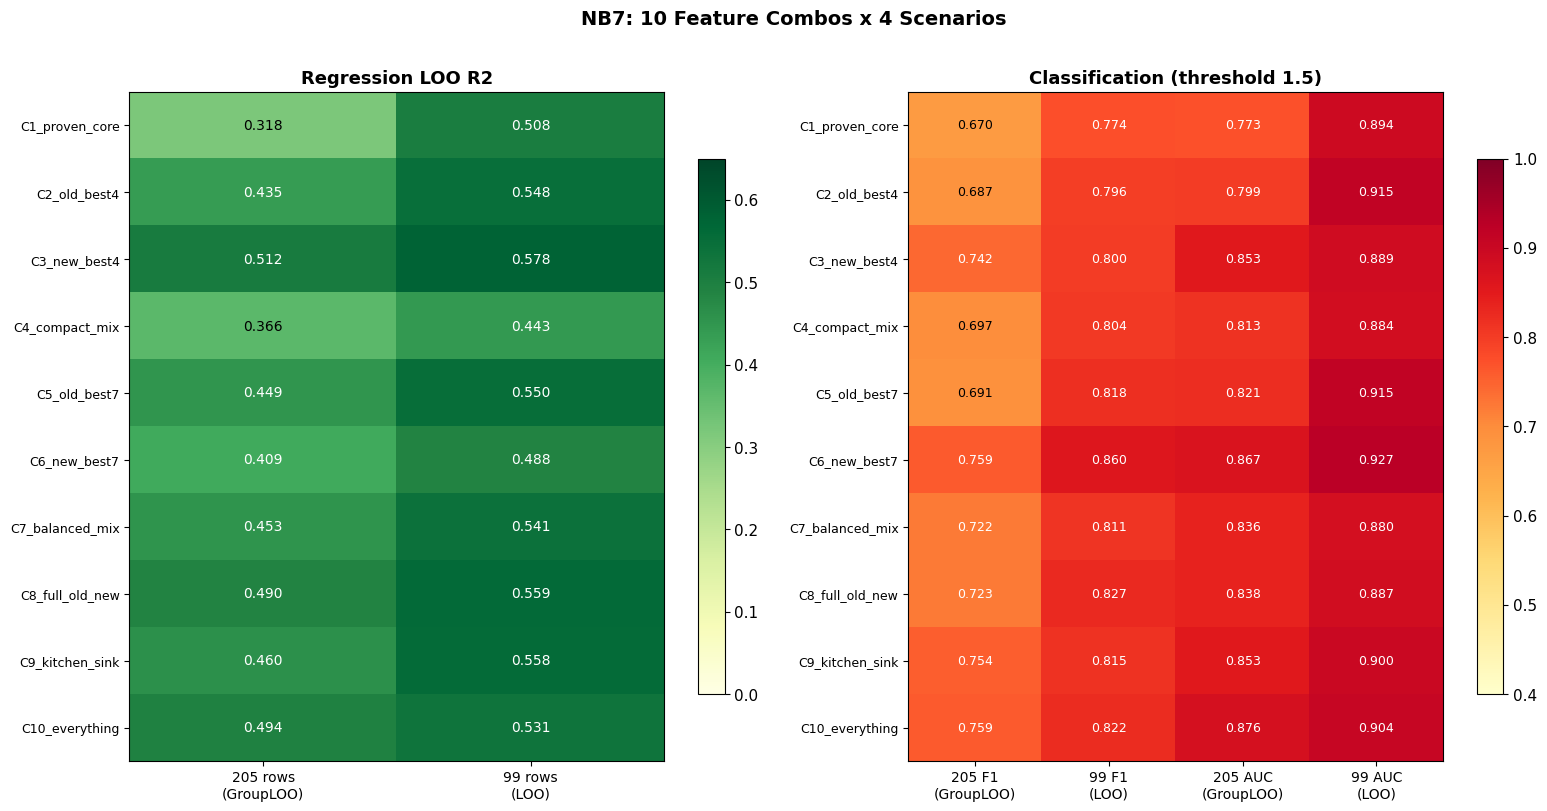

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Regression heatmap
reg_data = results_df[['combo', 'reg205_r2', 'reg99_r2']].set_index('combo')
reg_data.columns = ['205 rows\n(GroupLOO)', '99 rows\n(LOO)']

ax = axes[0]
im = ax.imshow(reg_data.values, cmap='YlGn', aspect='auto', vmin=0, vmax=0.65)
ax.set_xticks(range(len(reg_data.columns)))
ax.set_xticklabels(reg_data.columns, fontsize=10)
ax.set_yticks(range(len(reg_data.index)))
ax.set_yticklabels(reg_data.index, fontsize=9)
ax.set_title('Regression LOO R2', fontsize=13, fontweight='bold')
for i in range(len(reg_data.index)):
    for j in range(len(reg_data.columns)):
        val = reg_data.values[i, j]
        color = 'white' if val > 0.4 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)

# Classification heatmap
clf_data = results_df[['combo', 'clf205_f1', 'clf99_f1', 'clf205_auc', 'clf99_auc']].set_index('combo')
clf_data.columns = ['205 F1\n(GroupLOO)', '99 F1\n(LOO)', '205 AUC\n(GroupLOO)', '99 AUC\n(LOO)']

ax = axes[1]
im2 = ax.imshow(clf_data.values, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(clf_data.columns)))
ax.set_xticklabels(clf_data.columns, fontsize=10)
ax.set_yticks(range(len(clf_data.index)))
ax.set_yticklabels(clf_data.index, fontsize=9)
ax.set_title('Classification (threshold 1.5)', fontsize=13, fontweight='bold')
for i in range(len(clf_data.index)):
    for j in range(len(clf_data.columns)):
        val = clf_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im2, ax=ax, shrink=0.8)

plt.suptitle('NB7: 10 Feature Combos x 4 Scenarios', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "heatmap_all_scenarios.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 11: R2 / F1 vs number of features

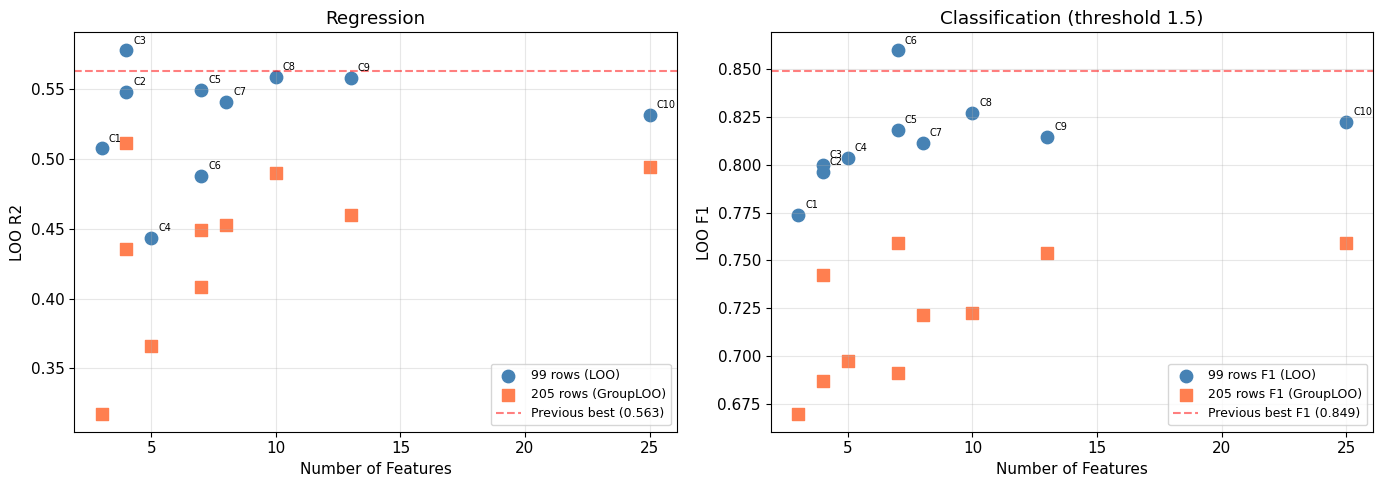

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression
ax = axes[0]
ax.scatter(results_df['n_feat'], results_df['reg99_r2'], s=80, color='steelblue', label='99 rows (LOO)')
ax.scatter(results_df['n_feat'], results_df['reg205_r2'], s=80, color='coral', marker='s', label='205 rows (GroupLOO)')
ax.axhline(y=0.563, color='red', linestyle='--', alpha=0.5, label='Previous best (0.563)')
ax.set_xlabel('Number of Features')
ax.set_ylabel('LOO R2')
ax.set_title('Regression')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for _, row in results_df.iterrows():
    ax.annotate(row['combo'].split('_')[0], (row['n_feat'], row['reg99_r2']),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

# Classification
ax = axes[1]
ax.scatter(results_df['n_feat'], results_df['clf99_f1'], s=80, color='steelblue', label='99 rows F1 (LOO)')
ax.scatter(results_df['n_feat'], results_df['clf205_f1'], s=80, color='coral', marker='s', label='205 rows F1 (GroupLOO)')
ax.axhline(y=0.849, color='red', linestyle='--', alpha=0.5, label='Previous best F1 (0.849)')
ax.set_xlabel('Number of Features')
ax.set_ylabel('LOO F1')
ax.set_title('Classification (threshold 1.5)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for _, row in results_df.iterrows():
    ax.annotate(row['combo'].split('_')[0], (row['n_feat'], row['clf99_f1']),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "scatter_nfeat_vs_score.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 12: Predicted vs Actual for best combos

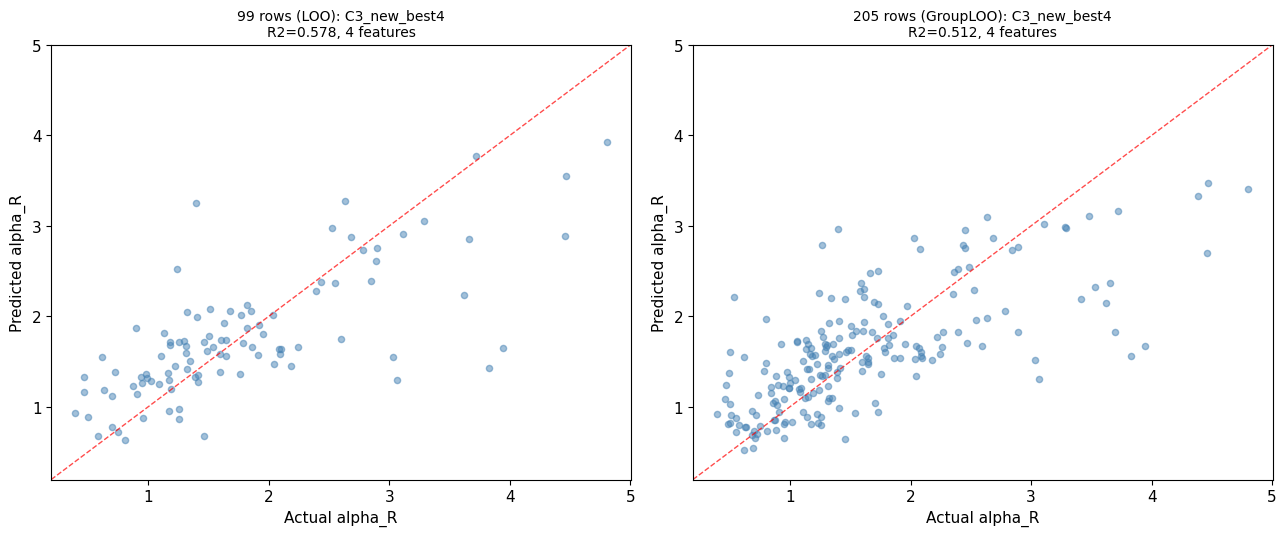

In [12]:
# Find best combo for each scenario
best_reg99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_reg205 = results_df.loc[results_df['reg205_r2'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for idx, (label, best_row, df_use, y_use, use_groups) in enumerate([
    ("99 rows (LOO)", best_reg99, df_99, y_99, False),
    ("205 rows (GroupLOO)", best_reg205, df_merged, y_205, True),
]):
    feats = [f.strip() for f in best_row['features'].split(',')]
    X = df_use[feats].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)

    if use_groups:
        cv = LeaveOneGroupOut()
        y_pred = cross_val_predict(model, X, y_use, cv=cv, groups=groups_205)
    else:
        y_pred = cross_val_predict(model, X, y_use, cv=LeaveOneOut())

    ax = axes[idx]
    ax.scatter(y_use, y_pred, alpha=0.5, s=20, color='steelblue')
    lims = [min(y_use.min(), y_pred.min()) - 0.2, max(y_use.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', lw=1, alpha=0.7)
    ax.set_xlabel('Actual alpha_R')
    ax.set_ylabel('Predicted alpha_R')
    r2_val = best_row['reg99_r2'] if not use_groups else best_row['reg205_r2']
    ax.set_title(f"{label}: {best_row['combo']}\nR2={r2_val:.3f}, {len(feats)} features", fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pred_vs_actual_best.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 13: Feature importance for top combos

  FEATURE IMPORTANCE (XGBoost, trained on full data)

C3_new_best4 (99-row R2=0.578):
  pmid_afs_gauss_std                      : 0.3725
  old_ehull                               : 0.2491
  old_E_pfrac_relevant                    : 0.2065
  old_kpath_angle_deg                     : 0.1719

C8_full_old_new (99-row R2=0.559):
  pstart_afs_gauss_std                    : 0.2361
  pmid_afs_gauss_std                      : 0.1688
  old_ehull                               : 0.1477
  old_E_pfrac_relevant                    : 0.1389
  old_radius_mean                         : 0.1073
  old_kpath_angle_deg                     : 0.0839
  pmid_grdf_trig_max                      : 0.0464
  mid_nearest_Z                           : 0.0301
  old_band_binary                         : 0.0283
  mid_nearest_Z4                          : 0.0125

C9_kitchen_sink (99-row R2=0.558):
  mid_adf_n_triplets                      : 0.2505
  pstart_afs_gauss_std                    : 0.2093
  old_E_pfrac_CBM         

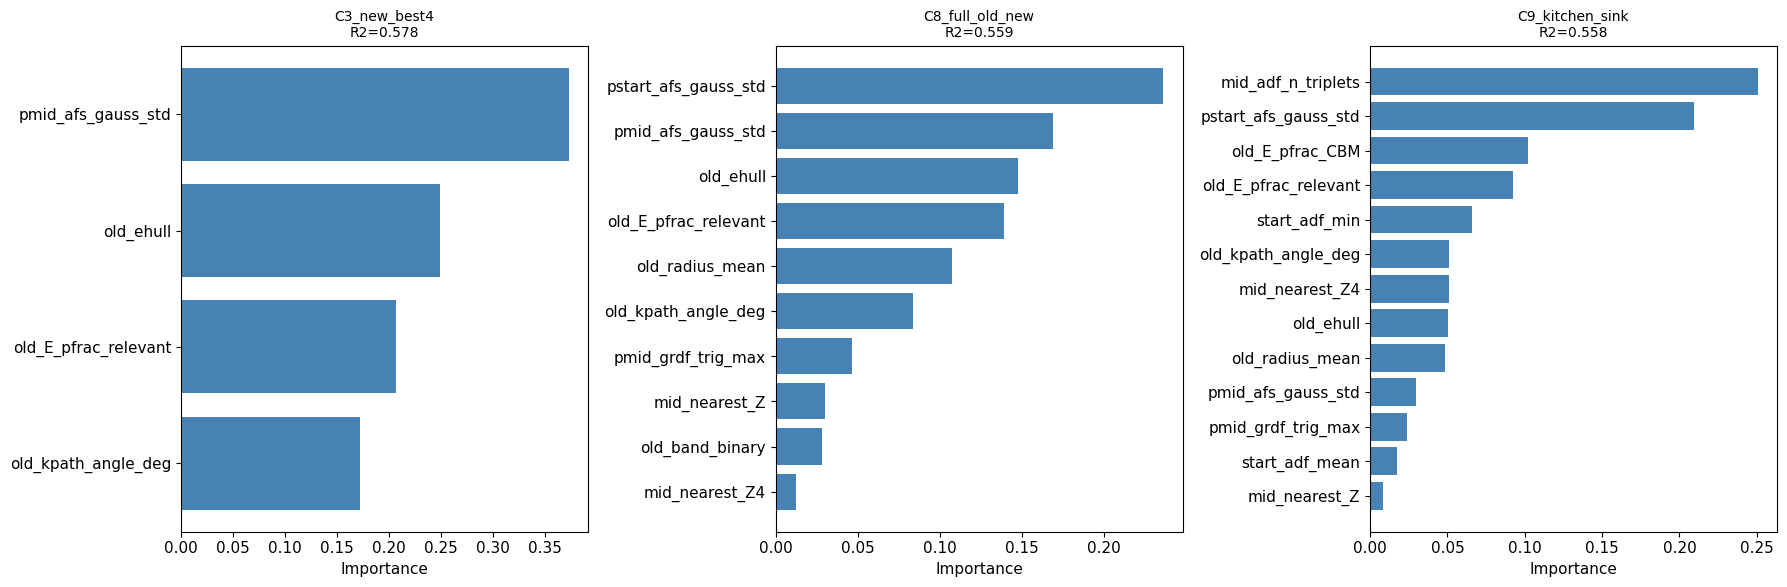

In [13]:
print("=" * 80)
print("  FEATURE IMPORTANCE (XGBoost, trained on full data)")
print("=" * 80)

# Top 3 combos by 99-row R2
top3 = results_df.nlargest(3, 'reg99_r2')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (_, row) in enumerate(top3.iterrows()):
    feats = [f.strip() for f in row['features'].split(',')]
    X = df_99[feats].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    model.fit(X, y_99)

    imp = model.feature_importances_
    imp_df = pd.DataFrame({'feature': feats, 'importance': imp}).sort_values('importance', ascending=True)

    ax = axes[idx]
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f"{row['combo']}\nR2={row['reg99_r2']:.3f}", fontsize=10)

    print(f"\n{row['combo']} (99-row R2={row['reg99_r2']:.3f}):")
    for _, r in imp_df.sort_values('importance', ascending=False).iterrows():
        print(f"  {r['feature']:40s}: {r['importance']:.4f}")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance_top3.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 14: Save merged CSV

In [14]:
# Save the merged 205-row CSV with all features from both old and new
merged_output = os.path.join(RESULTS_DIR, "merged_old_new_205.csv")
df_merged.to_csv(merged_output, index=False)
print(f"Saved merged CSV: {merged_output}")

# Save the 99-row collapsed version
collapsed_output = os.path.join(RESULTS_DIR, "merged_old_new_99.csv")
df_99.to_csv(collapsed_output, index=False)
print(f"Saved collapsed CSV: {collapsed_output}")

Saved merged CSV: .\nb7_combined-results\merged_old_new_205.csv
Saved collapsed CSV: .\nb7_combined-results\merged_old_new_99.csv


## Cell 15: Summary

In [15]:
print("=" * 80)
print("  NB7 COMPLETE -- SUMMARY")
print("=" * 80)

print(f"\n  10 feature combinations tested on 4 scenarios each")
print(f"  205 rows: GroupLeaveOneOut by uid (no compound leakage)")
print(f"  99 rows:  Standard LOO (one compound per row)")
print(f"  Classification threshold: {THRESHOLD}")

print(f"\n  REGRESSION (LOO R2):")
print(f"  {'Combo':<25s} {'205 rows':>10s} {'99 rows':>10s} {'#feat':>6s}")
print(f"  {'-'*55}")
for _, row in results_df.sort_values('reg99_r2', ascending=False).iterrows():
    print(f"  {row['combo']:<25s} {row['reg205_r2']:>10.4f} {row['reg99_r2']:>10.4f} {row['n_feat']:>6d}")

print(f"\n  CLASSIFICATION (LOO F1):")
print(f"  {'Combo':<25s} {'205 rows':>10s} {'99 rows':>10s} {'#feat':>6s}")
print(f"  {'-'*55}")
for _, row in results_df.sort_values('clf99_f1', ascending=False).iterrows():
    print(f"  {row['combo']:<25s} {row['clf205_f1']:>10.4f} {row['clf99_f1']:>10.4f} {row['n_feat']:>6d}")

print(f"\n  Previous best references:")
print(f"    Regression 99:     R2 = 0.563 (3 feat)")
print(f"    Classification 99: F1 = 0.849, AUC = 0.907 (5 feat)")

print(f"\n  All results: {RESULTS_DIR}/all_results.csv")
print(f"  Merged CSVs: merged_old_new_205.csv, merged_old_new_99.csv")

  NB7 COMPLETE -- SUMMARY

  10 feature combinations tested on 4 scenarios each
  205 rows: GroupLeaveOneOut by uid (no compound leakage)
  99 rows:  Standard LOO (one compound per row)
  Classification threshold: 1.5

  REGRESSION (LOO R2):
  Combo                       205 rows    99 rows  #feat
  -------------------------------------------------------
  C3_new_best4                  0.5116     0.5778      4
  C8_full_old_new               0.4899     0.5591     10
  C9_kitchen_sink               0.4601     0.5580     13
  C5_old_best7                  0.4494     0.5496      7
  C2_old_best4                  0.4354     0.5483      4
  C7_balanced_mix               0.4527     0.5407      8
  C10_everything                0.4942     0.5314     25
  C1_proven_core                0.3176     0.5076      3
  C6_new_best7                  0.4085     0.4878      7
  C4_compact_mix                0.3658     0.4432      5

  CLASSIFICATION (LOO F1):
  Combo                       205 rows    99 

In [16]:
# %% [markdown]
# ## Cell 16: Multi-model test (RF, SVR, XGBoost) + radius_mean boost check
#
# Test top 5 regression combos with 3 models on 99 rows.
# Also test: what happens if we ADD radius_mean to combos that don't have it?

# %%
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models to test
MODELS = {
    'XGBoost': XGBRegressor(**XGB_REG_PARAMS),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'SVR_RBF': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma='scale'))]),
}

# Top 5 combos from regression results + variants with radius_mean added
top5_reg = results_df.nlargest(5, 'reg99_r2')

# Build test combos: original + with radius_mean added
test_combos = {}
for _, row in top5_reg.iterrows():
    name = row['combo']
    feats_205 = [f.strip() for f in row['features'].split(',')]
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
    test_combos[name] = feats_99
    
    # Add radius_mean variant if not already present
    has_radius = any('radius_mean' in f for f in feats_99)
    if not has_radius:
        rm_col = 'radius_mean' if 'radius_mean' in df_99.columns else None
        if rm_col is None:
            for c in df_99.columns:
                if 'radius_mean' in c:
                    rm_col = c
                    break
        if rm_col:
            test_combos[f"{name}+rm"] = feats_99 + [rm_col]

# Also test the original Stage 2 winner for reference
if 'E_pfrac_VBM' in df_99.columns and 'E_pfrac_CBM' in df_99.columns:
    rm_col = 'radius_mean' if 'radius_mean' in df_99.columns else [c for c in df_99.columns if 'radius_mean' in c][0]
    test_combos['Stage2_original'] = ['E_pfrac_VBM', 'E_pfrac_CBM', rm_col]

print("=" * 90)
print("  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)")
print("=" * 90)
print(f"\n  Models: {list(MODELS.keys())}")
print(f"  Combos: {len(test_combos)}")

multi_results = []

for combo_name, feats in test_combos.items():
    # Verify all features exist
    missing = [f for f in feats if f not in df_99.columns]
    if missing:
        print(f"\n  SKIP {combo_name}: missing {missing}")
        continue
    
    X = df_99[feats].fillna(0).values
    print(f"\n  {combo_name} ({len(feats)} feat): {feats}")
    
    for model_name, model in MODELS.items():
        try:
            y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
            r2 = r2_score(y_99, y_pred)
            mae = mean_absolute_error(y_99, y_pred)
            
            multi_results.append({
                'combo': combo_name,
                'model': model_name,
                'n_feat': len(feats),
                'loo_r2': r2,
                'loo_mae': mae,
                'features': ', '.join(feats),
            })
            print(f"    {model_name:15s}: R2={r2:.4f}, MAE={mae:.4f}")
        except Exception as e:
            print(f"    {model_name:15s}: ERROR {e}")

multi_df = pd.DataFrame(multi_results)
multi_df.to_csv(os.path.join(RESULTS_DIR, "multi_model_results.csv"), index=False)

# Summary: best per combo across models
print(f"\n{'='*90}")
print("  BEST MODEL PER COMBO (99-row LOO R2)")
print(f"{'='*90}")
print(f"\n  {'Combo':<30s} {'Model':<15s} {'#feat':>5s} {'R2':>8s} {'MAE':>8s}")
print(f"  {'-'*70}")

for combo_name in test_combos.keys():
    subset = multi_df[multi_df['combo'] == combo_name]
    if len(subset) == 0:
        continue
    best = subset.loc[subset['loo_r2'].idxmax()]
    marker = " <-- +radius_mean" if "+rm" in combo_name else ""
    marker = " <-- REFERENCE" if "Stage2" in combo_name else marker
    print(f"  {best['combo']:<30s} {best['model']:<15s} {best['n_feat']:>5d} {best['loo_r2']:>8.4f} {best['loo_mae']:>8.4f}{marker}")

# Show radius_mean impact
print(f"\n{'='*90}")
print("  RADIUS_MEAN IMPACT")
print(f"{'='*90}")
for combo_name in test_combos.keys():
    if "+rm" not in combo_name:
        continue
    base_name = combo_name.replace("+rm", "")
    base_best = multi_df[multi_df['combo'] == base_name]['loo_r2'].max()
    rm_best = multi_df[multi_df['combo'] == combo_name]['loo_r2'].max()
    delta = rm_best - base_best
    print(f"  {base_name}: {base_best:.4f} -> +radius_mean: {rm_best:.4f} (delta={delta:+.4f})")

# Classification quick check on top 3 combos
print(f"\n{'='*90}")
print("  CLASSIFICATION (99-row LOO, threshold 1.5) -- Top 3 combos")
print(f"{'='*90}")

top3_names = multi_df.groupby('combo')['loo_r2'].max().nlargest(3).index.tolist()
for combo_name in top3_names:
    feats = test_combos[combo_name]
    missing = [f for f in feats if f not in df_99.columns]
    if missing:
        continue
    X = df_99[feats].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    y_pred = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut())
    try:
        y_prob = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut(), method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_99, y_prob)
    except:
        auc = np.nan
    f1 = f1_score(y_class_99, y_pred)
    print(f"  {combo_name}: F1={f1:.4f}, AUC={auc:.4f}")

  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)

  Models: ['XGBoost', 'RandomForest', 'GradBoosting', 'SVR_RBF']
  Combos: 8

  C3_new_best4 (5 feat): ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'old_ehull', 'pmid_afs_gauss_std', 'old_kpath_angle_deg']
    XGBoost        : R2=0.5778, MAE=0.4525
    RandomForest   : R2=0.4962, MAE=0.4874
    GradBoosting   : R2=0.5499, MAE=0.4730
    SVR_RBF        : R2=0.5358, MAE=0.4721

  C3_new_best4+rm (6 feat): ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'old_ehull', 'pmid_afs_gauss_std', 'old_kpath_angle_deg', 'old_radius_mean']
    XGBoost        : R2=0.5970, MAE=0.4522
    RandomForest   : R2=0.5146, MAE=0.4866
    GradBoosting   : R2=0.5627, MAE=0.4517
    SVR_RBF        : R2=0.4275, MAE=0.4908

  C8_full_old_new (10 feat): ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'mid_nearest_Z', 'mid_nearest_Z4', 'old_kpath_angle_deg', 'pmid_grdf_trig_max', 'old_ehull', 'pmid_afs_gauss_std', 'old_radius_mean', 'pstart_afs_gauss_std']
    XGBoost        : R2=0.5591, MAE=0.462